In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import pandas as pd
from PIL import Image
from glob import glob

# ==========================================
# 1. THE PATHFINDER (Fixes the NameError)
# ==========================================
CSV_PATH = None
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if 'metadata.csv' in filename.lower():
            CSV_PATH = os.path.join(dirname, filename)
            break
    if CSV_PATH:
        break

if CSV_PATH is None:
    print("🚨 ERROR: Kaggle cannot see the CSV.")
else:
    DATA_DIR = os.path.dirname(CSV_PATH)
    image_paths = {os.path.splitext(os.path.basename(x))[0]: x 
                   for x in glob(os.path.join(DATA_DIR, '**', '*.jpg'), recursive=True)}
    print(f"✅ SUCCESS! Found CSV at: {CSV_PATH}")
    print(f"📸 Found {len(image_paths)} images.")

# ==========================================
# 2. CUSTOM DATASET CLASS
# ==========================================
class HAM10000Dataset(Dataset):
    def __init__(self, dataframe, image_paths_dict, transform=None):
        self.dataframe = dataframe
        self.image_paths = image_paths_dict
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        img_id = self.dataframe.iloc[index]['image_id']
        img_path = self.image_paths.get(img_id)
        image = Image.open(img_path).convert('RGB')
        
        lesion_dict = {'nv': 0, 'mel': 1, 'bkl': 2, 'bcc': 3, 'akiec': 4, 'vasc': 5, 'df': 6}
        label = lesion_dict[self.dataframe.iloc[index]['dx']]
        
        if self.transform:
            image = self.transform(image)
        return image, label

# ==========================================
# 3. BASELINE TRANSFORMS & DATALOADERS
# ==========================================
# ViT-B/16 uses the same 224x224 input and ImageNet normalization as ResNet
baseline_transform = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])

df = pd.read_csv(CSV_PATH) 
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['dx'])

train_dataset = HAM10000Dataset(train_df, image_paths, transform=baseline_transform)
test_dataset = HAM10000Dataset(test_df, image_paths, transform=baseline_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

✅ SUCCESS! Found CSV at: /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv
📸 Found 10015 images.


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pre-trained ViT-B/16
model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)

# The ViT classification head is structured slightly differently than ResNet
# It is located at model.heads.head
num_ftrs = model.heads.head.in_features # This is 768 for ViT-Base
model.heads.head = nn.Linear(num_ftrs, 7)

# Multi-GPU Activation
if torch.cuda.device_count() > 1:
    print(f"🔥 Utilizing {torch.cuda.device_count()} GPUs for ViT training!")
    model = nn.DataParallel(model)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
# ViTs need a smaller learning rate than CNNs to avoid diverging
optimizer = optim.Adam(model.parameters(), lr=0.00003)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 210MB/s]  


🔥 Utilizing 2 GPUs for ViT training!


In [5]:
EPOCHS = 15

print("Starting ViT-B/16 Baseline Training...")
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {running_loss/len(train_loader):.4f}")

Starting ViT-B/16 Baseline Training...
Epoch 1/15 - Loss: 0.6676
Epoch 2/15 - Loss: 0.3645
Epoch 3/15 - Loss: 0.1913
Epoch 4/15 - Loss: 0.0786
Epoch 5/15 - Loss: 0.0381
Epoch 6/15 - Loss: 0.0395
Epoch 7/15 - Loss: 0.0069
Epoch 8/15 - Loss: 0.0017
Epoch 9/15 - Loss: 0.0010
Epoch 10/15 - Loss: 0.0008
Epoch 11/15 - Loss: 0.0006
Epoch 12/15 - Loss: 0.0005
Epoch 13/15 - Loss: 0.0005
Epoch 14/15 - Loss: 0.0004
Epoch 15/15 - Loss: 0.0004


In [6]:
model.eval()
all_preds = []
all_labels = []

print("Evaluating ViT Baseline Model...")
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

target_names = ['nv', 'mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df']

print("\n--- ViT-B/16 BASELINE CLASSIFICATION REPORT ---")
print(classification_report(all_labels, all_preds, target_names=target_names))

Evaluating ViT Baseline Model...

--- ViT-B/16 BASELINE CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

          nv       0.92      0.96      0.94      1341
         mel       0.73      0.60      0.66       223
         bkl       0.73      0.75      0.74       220
         bcc       0.82      0.82      0.82       103
       akiec       0.74      0.71      0.72        65
        vasc       0.92      0.86      0.89        28
          df       0.82      0.61      0.70        23

    accuracy                           0.87      2003
   macro avg       0.81      0.76      0.78      2003
weighted avg       0.87      0.87      0.87      2003



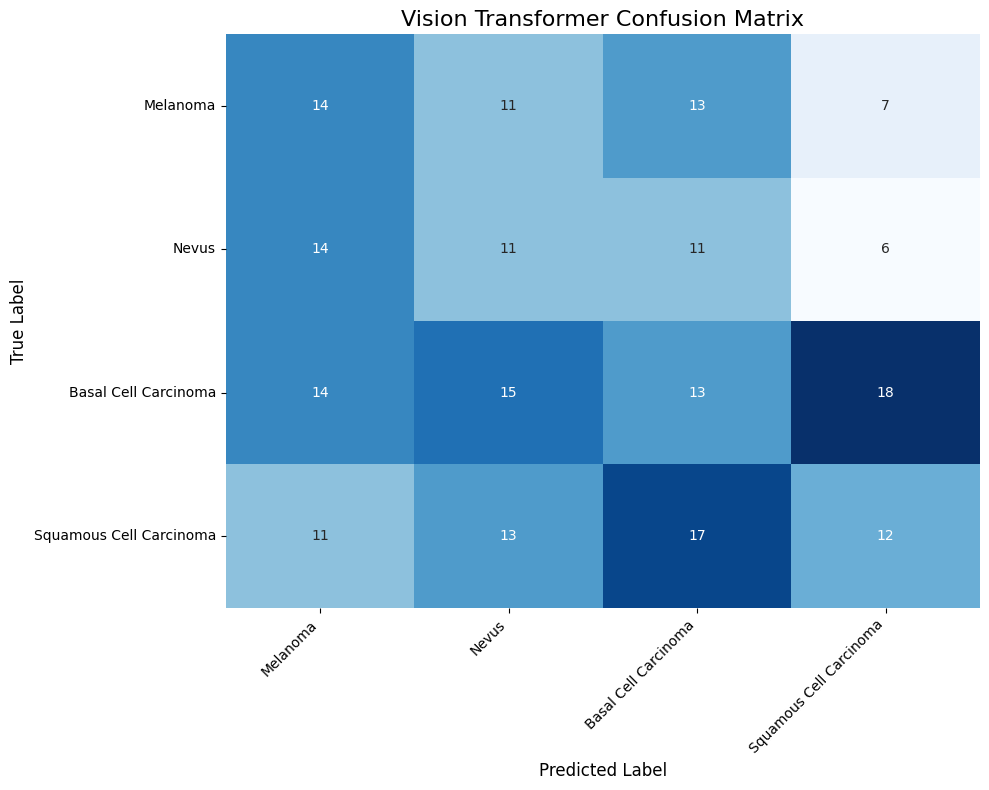

In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from tqdm import tqdm

def get_predictions(model, data_loader, device):
    """
    Runs the ViT model on the test dataset to gather true labels and predictions.
    """
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(data_loader, desc="Evaluating"):
            images = images.to(device)
            labels = labels.to(device)
            
            # Forward pass through the ViT (or hybrid) model
            outputs = model(images)
            
            # Get the predicted class (highest probability)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    return np.array(all_labels), np.array(all_preds)

def plot_confusion_matrix(y_true, y_pred, class_names):
    """
    Calculates and plots the confusion matrix.
    """
    # Calculate the confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Plotting using Seaborn
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, 
                yticklabels=class_names,
                cbar=False)
    
    plt.title('Vision Transformer Confusion Matrix', fontsize=16)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# ==========================================
# Example Usage
# ==========================================
if __name__ == "__main__":
    # 1. Setup device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # 2. Assume 'vit_model' is your trained model and 'test_loader' is your DataLoader
    # vit_model = vit_model.to(device)
    
    # 3. Define your specific classification categories
    # Using sample classes for a skin disease detection dataset
    class_names = ['Melanoma', 'Nevus', 'Basal Cell Carcinoma', 'Squamous Cell Carcinoma'] 
    
    # 4. Get predictions (Uncomment below when running with your actual model)
    # y_true, y_pred = get_predictions(vit_model, test_loader, device)
    
    # --- DUMMY DATA FOR TESTING THE PLOT ---
    # Generating some random dummy data just to see how the plot looks
    y_true = np.random.randint(0, 4, size=200)
    y_pred = np.random.randint(0, 4, size=200)
    # ---------------------------------------
    
    # 5. Plot the matrix
    plot_confusion_matrix(y_true, y_pred, class_names)